In [3]:
import numpy as np
import tensorflow_datasets as tfds  # pip install tensorflow-datasets
import tensorflow as tf
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.applications import EfficientNetB0

In [4]:
DATA_DIR = "./pill_datasets"

IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 123

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("클래스 수:", NUM_CLASSES)
print(class_names[:5])

Found 711 files belonging to 427 classes.
Using 569 files for training.
Found 711 files belonging to 427 classes.
Using 142 files for validation.
클래스 수: 427
['200102789_잔타놀정', '200308619_리리스정', '200403661_에너지톤연질캡슐', '200600140_라시핀정(라시디핀)', '200607723_포스펜정']


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [8]:
def build_model():

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augmentation(inputs)

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )

    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [12]:
model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ sequential[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,601,678 (17.55 MB)

 Trainable params: 549,547 (2.10 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [13]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True
    ),

    keras.callbacks.ModelCheckpoint(
        "pill_efficientnet_b0.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [14]:
EPOCHS = 30

hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 231ms/step - accuracy: 0.0018 - loss: 6.6563 - val_accuracy: 0.0141 - val_loss: 5.9588
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - accuracy: 0.1072 - loss: 4.8750 - val_accuracy: 0.0352 - val_loss: 5.7420
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.3339 - loss: 3.3212 - val_accuracy: 0.0493 - val_loss: 5.4965
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step - accuracy: 0.5009 - loss: 2.4609 - val_accuracy: 0.0986 - val_loss: 5.2356
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - accuracy: 0.6362 - loss: 1.7968 - val_accuracy: 0.1197 - val_loss: 5.0437
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.7135 - loss: 1.3489 - val_accuracy: 0.1761 - val_loss: 4.8248
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 198ms/step - accuracy: 0.7803 - loss: 1.0330 - val_accuracy: 0.1549 - val_loss: 4.7366
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step - accuracy: 0.8383 - loss: 0.8061 - val_accuracy: 0

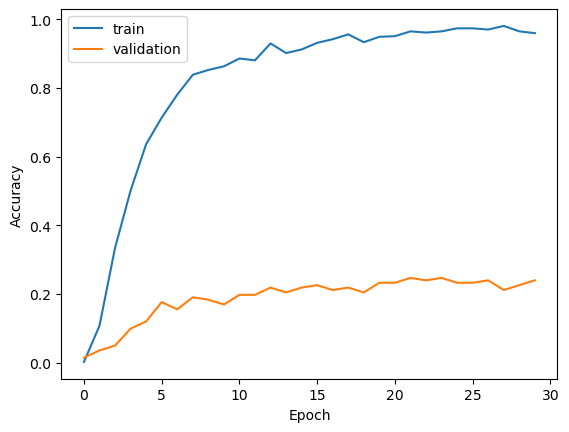

In [15]:
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])

plt.legend(["train", "validation"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

In [17]:
img = tf.keras.utils.load_img(
    "200704968_토핀정25밀리그램(토피라메이트)_0cdlkokvpq8lj02__seg02__sports_ball__0.350.png",
    target_size=(224,224)
)

img = tf.keras.utils.img_to_array(img)
img = tf.expand_dims(img, 0)

pred = model.predict(img)

idx = tf.argmax(pred[0]).numpy()

print("예측 결과:", class_names[idx])
print("확률:", float(pred[0][idx]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
예측 결과: 201103627_미그펜400연질캡슐(이부프로펜)
확률: 0.5549949407577515


In [18]:
model.save("pill_efficientnet_b0_final.keras")

In [19]:
import json

with open("pill_history.json", "w", encoding="utf-8") as f:
    json.dump(hist.history, f)

In [20]:
import pandas as pd

pd.DataFrame(hist.history).to_csv(
    "pill_history.csv",
    index=False,
    encoding="utf-8-sig"
)